(graph-engine)=
# Graph

Once you have a serving function, you need to choose the graph topology:
* [Router topology](#router)
* [Flow topology](#flow)
```{note} Once the topology is set, you cannot change an existing function topology.
```

## Router

The default topology is the `router` topology. It is a minimal configuration with a single router and one or more child routes/models, used for simple model serving or 
single hop configurations. The basic routing logic is to route to the child routes based on the `event.path`.

With the `router` topology you can specify different machine learning models. Each model has a logical name. This name is used to route to the correct model when calling the serving function.

More advanced or custom routing can be used, for example, the ensemble router sends 
the event to all child routes in parallel, aggregates the result, and responds.




In [5]:
from sklearn.datasets import load_iris

# set the topology/router
graph = fn.set_topology("router")

# Add the model
fn.add_model(
    "model1",
    class_name="ClassifierModel",
    model_path="https://s3.wasabisys.com/iguazio/models/iris/model.pkl",
)

# Add additional models
# fn.add_model("model2", class_name="ClassifierModel", model_path="<path2>")

# create and use the graph simulator
server = fn.to_mock_server()
x = load_iris()["data"].tolist()
result = server.test("/v2/models/model1/infer", {"inputs": x})
server.wait_for_completion()

print(result)

> 2021-11-02 04:18:36,925 [info] model model1 was loaded
> 2021-11-02 04:18:36,926 [info] Initializing endpoint records
> 2021-11-02 04:18:36,965 [info] Loaded ['model1']
{'id': '6bd11e864805484ea888f58e478d1f91', 'model_name': 'model1', 'outputs': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]}


### Flow

The flow topology is a full graph/DAG. It is implemented using two engines: async (the default)
is based on [Storey](https://github.com/mlrun/storey) and asynchronous event loop; and `sync`, which supports a simple
sequence of steps. You can use the `flow` topology to specify tasks, which typically manipulate the data. The most common scenario is pre-processing of data prior to the model execution.

In this topology, you build and connect the graph (DAG) by adding steps using the `step.to()` method, or by using the 
`graph.add_step()` method.

The `step.to()` is typically used to chain steps together. `graph.add_step` can add steps anywhere on the
graph and has `before` and `after` parameters to specify the location of the step.

<!-- show example without router -->

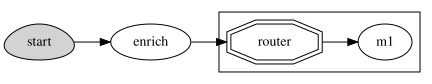

In [18]:
fn2 = project.set_function(
    name="serving_example_flow", kind="serving", image="mlrun/mlrun"
)

graph2 = fn2.set_topology("flow")

graph2_enrich = graph2.to("storey.Extend", name="enrich", _fn='({"tag": "something"})')

# add an Ensemble router with two child models (routes)
router = graph2.add_step(mlrun.serving.ModelRouter(), name="router", after="enrich")
router.add_route(
    "m1",
    class_name="ClassifierModel",
    model_path="https://s3.wasabisys.com/iguazio/models/iris/model.pkl",
)
router.respond()

# add an error handling step, run only when/if the "pre-process" step fails
graph.to(name="pre-process", handler="raising_step").error_handler(
    name="catcher", handler="handle_error", full_event=True
)

# Add additional models
# router.add_route("m2", class_name="ClassifierModel", model_path=path2)

# plot the graph (using Graphviz)
graph2.plot(rankdir="LR")

In [7]:
fn2_server = fn2.to_mock_server()

result = fn2_server.test("/v2/models/m1/infer", {"inputs": x})
fn2_server.wait_for_completion()

print(result)

> 2021-11-02 04:18:42,142 [info] model m1 was loaded
> 2021-11-02 04:18:42,142 [info] Initializing endpoint records
> 2021-11-02 04:18:42,183 [info] Loaded ['m1']
{'id': 'f713fd7eedeb431eba101b13c53a15b5'}
